# 🐧 Projeto 30 — Clustering de Pinguins com K-means
## 📌 Objetivo
Aplicar o algoritmo **K-means** para segmentar espécies de pinguins (Adelie, Chinstrap e Gentoo) com base em características físicas, validando o uso de clustering em dados biológicos.


## Ferramentas
Python | Pandas | NumPy | Seaborn | Matplotlib | Scikit-learn | K-means | 

## Etapas
1. Carregamento e exploração da base.  
2. Pré-processamento: tratamento de valores faltantes e padronização.  
3. Aplicação do **K-means** para identificar clusters.  
4. Visualização dos grupos formados.  
5. Comparação com as espécies reais.  

## Ferramentas
Python | Pandas | NumPy | Seaborn | Matplotlib | Scikit-learn  

## Resultado
Clusters bem definidos que refletem diferenças físicas entre as espécies, validando a aplicação do K-means em dados biológicos.

##  Variáveis da Base de Dados (penguins - Seaborn)

- **species** → Espécie do pinguim (Adelie, Chinstrap, Gentoo)  
- **island** → Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)  
- **bill_length_mm** → Comprimento do bico (mm)  
- **bill_depth_mm** → Profundidade do bico (mm)  
- **flipper_length_mm** → Comprimento da barbatana (mm)  
- **body_mass_g** → Massa corporal (g)  
- **sex** → Sexo do pinguim (Male, Female)  
- **year** → Ano da observação  


In [74]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [75]:
# Carregar dataset
penguins = sns.load_dataset('penguins')

# Visualizar dataset
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [76]:

# 1. Remover linhas com valores nulos
penguins_clean = penguins.dropna()

# 2. Excluir colunas categóricas
penguins_numeric = penguins_clean.drop(columns=['species', 'island', 'sex'])

# 3. Resetar índice para ficar sequencial
penguins_numeric = penguins_numeric.reset_index(drop=True)

# Visualizar resultado
print(penguins_numeric.shape)   # deve mostrar (333, 4)
print(penguins_numeric.head())


(333, 4)
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
3            36.7           19.3              193.0       3450.0
4            39.3           20.6              190.0       3650.0


###  Análise Exploratória

Análise da distribuição e relação entre as variáveis numéricas, diferenciando os pinguins por espécie.  
Essa visualização já permite observar padrões e levantar hipóteses sobre possíveis agrupamentos.

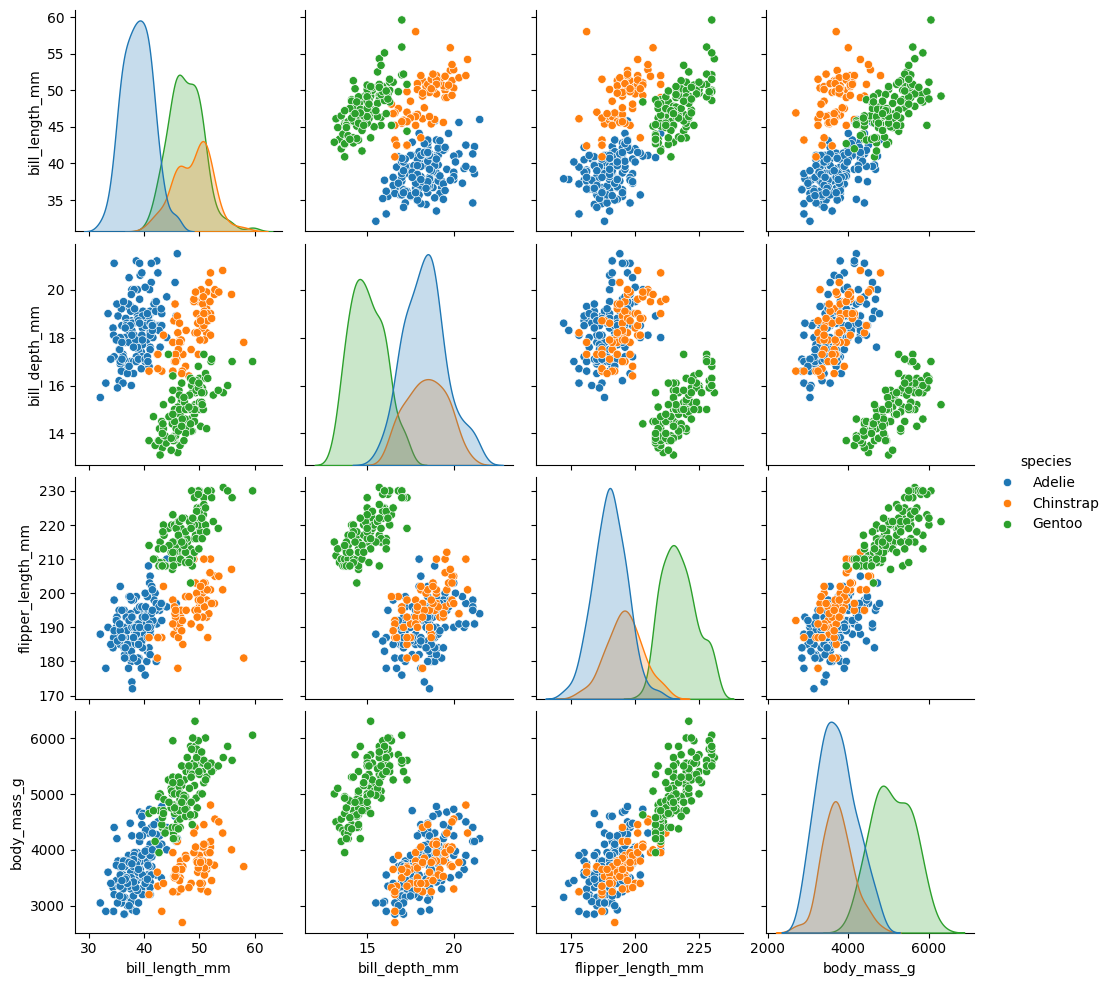

In [77]:
 # Visualização com Pairplot 

# Pairplot com as variáveis numéricas
sns.pairplot(penguins_clean, hue="species")
plt.show()


#### Identificação dos agrupamento:

* Gentoo: forma um grupo bem separado, caracterizado por valores maiores de flipper_length_mm e body_mass_g.

* Adelie: concentra-se em medidas menores de massa corporal e comprimento de asa, criando um agrupamento distinto.

* Chinstrap: aparece próximo dos Adelie em algumas variáveis, mas mantém um padrão próprio, configurando o terceiro grupo.

* Em resumo, **os três agrupamentos** refletem claramente as diferenças morfológicas entre as espécies, **reforçando que k=3** é um valor inicial adequado para aplicar KMeans.


In [78]:
from sklearn.preprocessing import StandardScaler

# Padronizar os dados numéricos
scaler = StandardScaler()
penguins_scaled = scaler.fit_transform(penguins_numeric)

# Converter de volta para DataFrame para visualizar
penguins_scaled_df = pd.DataFrame(
    penguins_scaled,
    columns=penguins_numeric.columns
)

# Visualizar primeiras linhas
print(penguins_scaled_df.head())


   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0       -0.896042       0.780732          -1.426752    -0.568475
1       -0.822788       0.119584          -1.069474    -0.506286
2       -0.676280       0.424729          -0.426373    -1.190361
3       -1.335566       1.085877          -0.569284    -0.941606
4       -0.859415       1.747026          -0.783651    -0.692852


In [79]:
# Criar uma cópia explícita do DataFrame limpo
penguins_clean = penguins_clean.copy()

# Agora adicionar a coluna de clusters sem warning
penguins_clean['cluster'] = clusters


In [80]:
# Aplicação do KMeans com 3 clusters, já que identificamos 3 espécies distintas no dataset.

from sklearn.cluster import KMeans

# Aplicar KMeans com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(penguins_scaled)

# Adicionar os clusters ao DataFrame original
penguins_clean['cluster'] = clusters

# Visualizar primeiras linhas com cluster atribuído
print(penguins_clean[['species', 'cluster']].head(10))


   species  cluster
0   Adelie        0
1   Adelie        0
2   Adelie        0
4   Adelie        0
5   Adelie        0
6   Adelie        0
7   Adelie        0
12  Adelie        0
13  Adelie        0
14  Adelie        0


In [81]:
# Verificando a distribuição por espécie
print(penguins_clean.groupby(['species', 'cluster']).size())


species    cluster
Adelie     0          124
           2           22
Chinstrap  0            5
           2           63
Gentoo     1          119
dtype: int64


#### Interpretação
Adelie: a maioria (124) caiu no cluster 0, mas 22 foram para o cluster 2.

Chinstrap: quase todos (63) ficaram no cluster 2, mas 5 foram para o cluster 0.

Gentoo: praticamente todos (119) ficaram no cluster 1, mostrando separação bem clara.

Isso mostra que o KMeans conseguiu identificar 3 agrupamentos principais:

Cluster 0 → majoritariamente Adelie.

Cluster 1 → praticamente só Gentoo.

Cluster 2 → majoritariamente Chinstrap, mas com alguns Adelie misturados.

Ou seja, o algoritmo conseguiu refletir bem a separação natural das espécies, embora haja alguma sobreposição entre Adelie e Chinstrap (o que já aparecia no pairplot).

## Construção de 2 matriz de dispersão, indicando os pontos e centroides.

**Gráfico 1 :  Uso do  x='bill_length_mm' e y='bill_depth_mm' para análise**
**Gráfico 2 :  Uso outras variaveis**

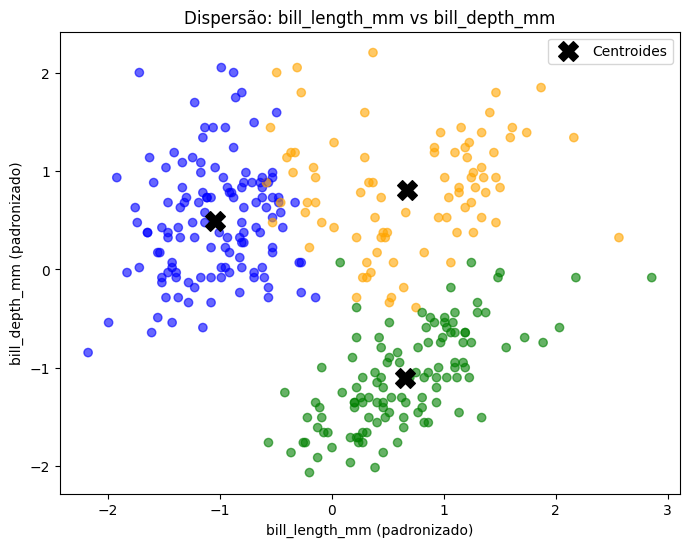

In [82]:
import matplotlib.pyplot as plt

# Obter centróides
centroids = kmeans.cluster_centers_

# Definir cores fixas iguais às espécies
color_map = {0: "blue", 1: "green", 2: "orange"}  
# Aqui você associa cada cluster à cor da espécie correspondente

# Primeiro gráfico: bill_length_mm vs bill_depth_mm
plt.figure(figsize=(8,6))
plt.scatter(penguins_scaled[:,0], penguins_scaled[:,1],
            c=[color_map[label] for label in clusters], alpha=0.6)
plt.scatter(centroids[:,0], centroids[:,1], c='black', s=200, marker='X', label='Centroides')
plt.xlabel('bill_length_mm (padronizado)')
plt.ylabel('bill_depth_mm (padronizado)')
plt.title('Dispersão: bill_length_mm vs bill_depth_mm')
plt.legend()
plt.show()


### 📈 Interpretação

- **Gráfico 1 (bill_length_mm vs bill_depth_mm):**  
  Separação parcial entre Adelie (azul) e Chinstrap (laranja). Gentoo (verde) não se diferencia bem nessa combinação.  
  *Insight:* útil para distinguir Adelie e Chinstrap, mas não Gentoo.

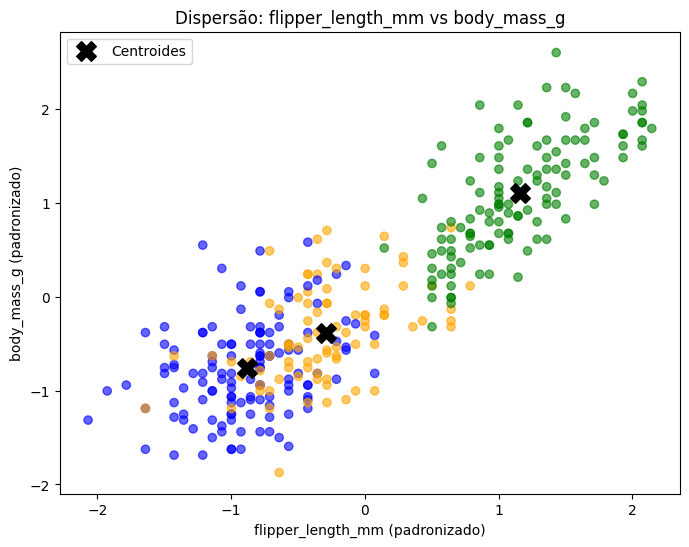

In [83]:
# Segundo gráfico: flipper_length_mm vs body_mass_g
plt.figure(figsize=(8,6))
plt.scatter(penguins_scaled[:,2], penguins_scaled[:,3],
            c=[color_map[label] for label in clusters], alpha=0.6)
plt.scatter(centroids[:,2], centroids[:,3], c='black', s=200, marker='X', label='Centroides')
plt.xlabel('flipper_length_mm (padronizado)')
plt.ylabel('body_mass_g (padronizado)')
plt.title('Dispersão: flipper_length_mm vs body_mass_g')
plt.legend()
plt.show()

### 📈 Interpretação

- **Gráfico 2 (flipper_length_mm vs body_mass_g):**  
  Separação clara: Gentoo isolado com maiores valores, Adelie em menores medidas e Chinstrap em posição intermediária.  
  *Insight:* essas variáveis são as melhores para diferenciar Gentoo dos demais.



#### Visualização dos agrupamentos, nome do dataframe de vocês e do modelo no código onde está o “kmeans” , rodar construir um breve Insight acerca dos grupos analisados.
*  Analise se os agrupamentos foram satisfatórios.
* Quais variáveis parecem permitir uma separação melhor?


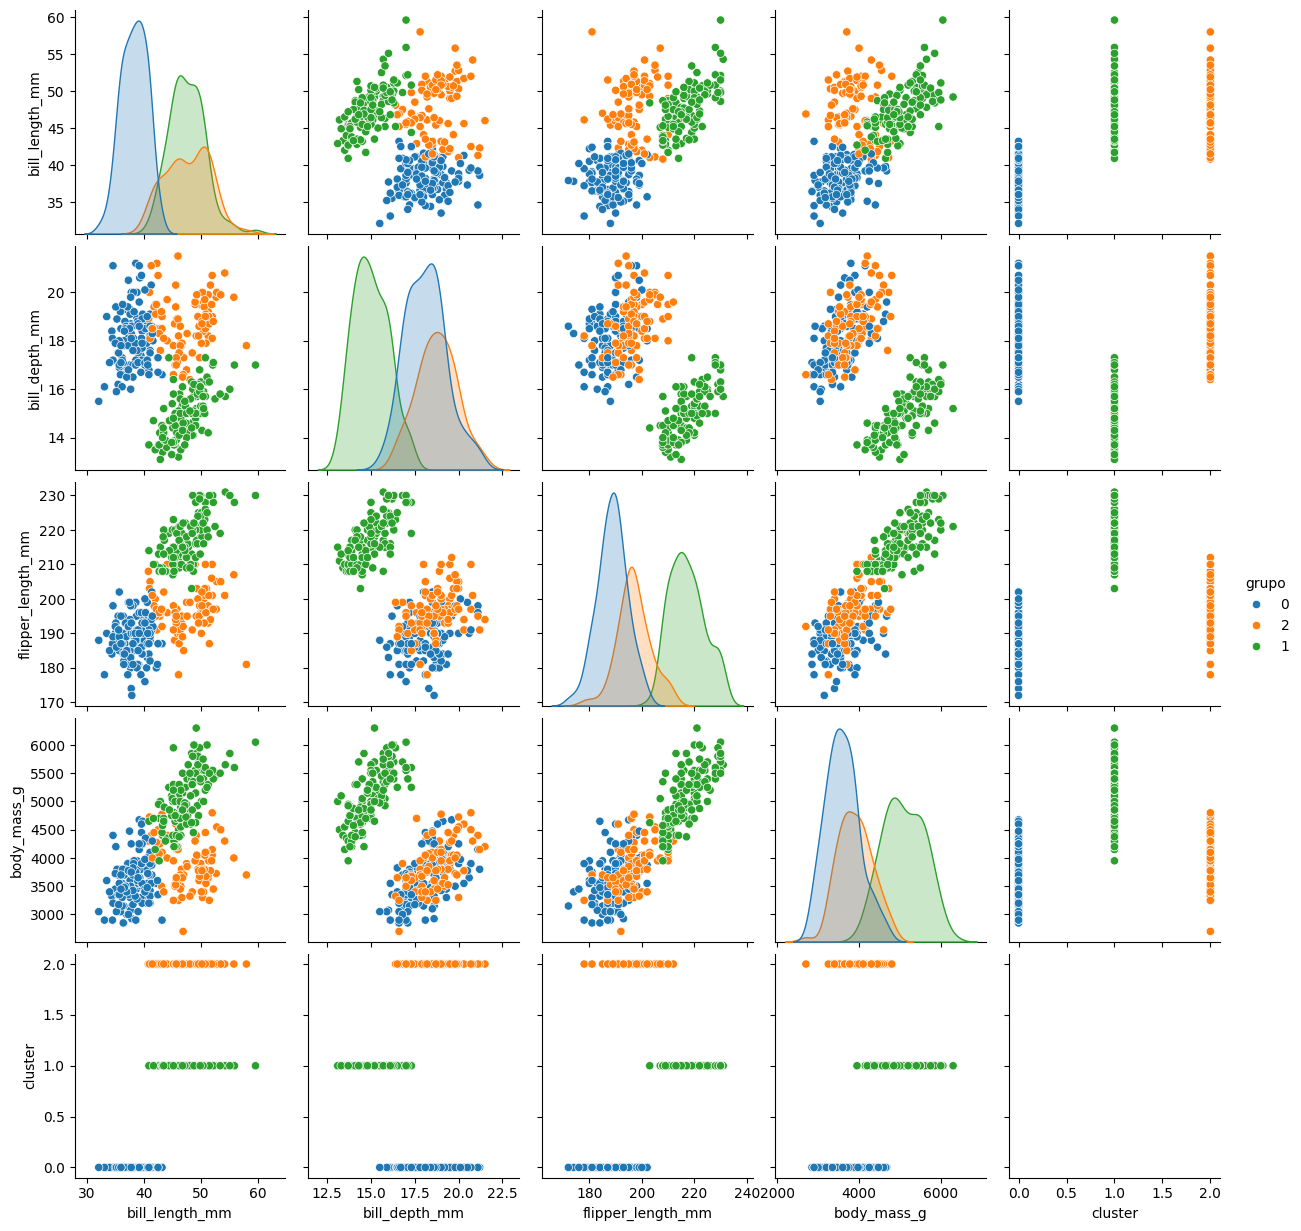

In [84]:
# Adiciona coluna 'grupo' com os rótulos do KMeans
penguins_clean['grupo'] = kmeans.labels_.astype(str)

# Pairplot mostrando os clusters formados pelo KMeans
import seaborn as sns
sns.pairplot(penguins_clean, hue='grupo')


#### Insight final resumido
**Insight:** O K-means separou bem os Gentoo (isolados por maior massa corporal e barbatana), enquanto Adelie e Chinstrap permanecem próximos, com sobreposição em algumas variáveis.  
**Conclusão:** Os agrupamentos foram satisfatórios, mas a distinção é mais clara para Gentoo do que entre Adelie e Chinstrap.


## Exemplos de três aplicações de algoritmos de clusterização
- **Segmentação de clientes**  
Agrupar consumidores por comportamento de compra ou perfil demográfico, permitindo campanhas de marketing mais direcionadas e personalizadas.

- **Agrupamento de documentos**  
Organizar grandes coleções de textos (artigos, notícias, e-mails) em grupos temáticos, facilitando buscas, recomendações e análise de informação.

- **Análise genética**  
Identificar padrões em dados de DNA ou RNA, agrupando indivíduos ou espécies com características genéticas semelhantes, apoiando pesquisas médicas e evolutivas.